In [1]:
SIM_FILE = '/datascope/subaru/user/swei20/data/bosz50000/z1/mag205_225_lowT_1M/train_200k_0/dataset.h5'
TRAINING_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0.npz'
DENOISED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_N50000.npz'
DENOISED_MASK = '/datascope/subaru/user/swei20/model/bosz50000_mask.npy'

N = 10000

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from collections import defaultdict
from tqdm.notebook import tqdm

from astropy.coordinates import SpectralCoord
import astropy.units as u
import specutils

In [3]:
plt.rcParams["text.usetex"] = True

# Load the simulation

In [4]:
# Load the pandas DataFrame from the HDF5 file stored in /dataset/params/table
with h5py.File(SIM_FILE, 'r') as f:
    params = pd.read_hdf(SIM_FILE, key='dataset/params')

params.shape

(200000, 35)

In [5]:
# # Select only those spectra that were interpolated in the log g direction
# data_mask = params['interp_param'] == PARAM

# Include all spectra
data_mask = np.full_like(params['interp_param'], True)

data_idx = np.where(data_mask)[0]
data_mask.sum()

200000

In [6]:
# Load the selected spectra from the HDF5 file
with h5py.File(SIM_FILE, 'r') as f:
    wave = f['spectrumdataset/wave'][:]
    flux = f['dataset/arrays/flux/value'][data_idx[:N], :]
    flux_err = f['dataset/arrays/error/value'][data_idx[:N], :]

wave.shape, flux.shape, flux_err.shape

((4096,), (10000, 4096), (10000, 4096))

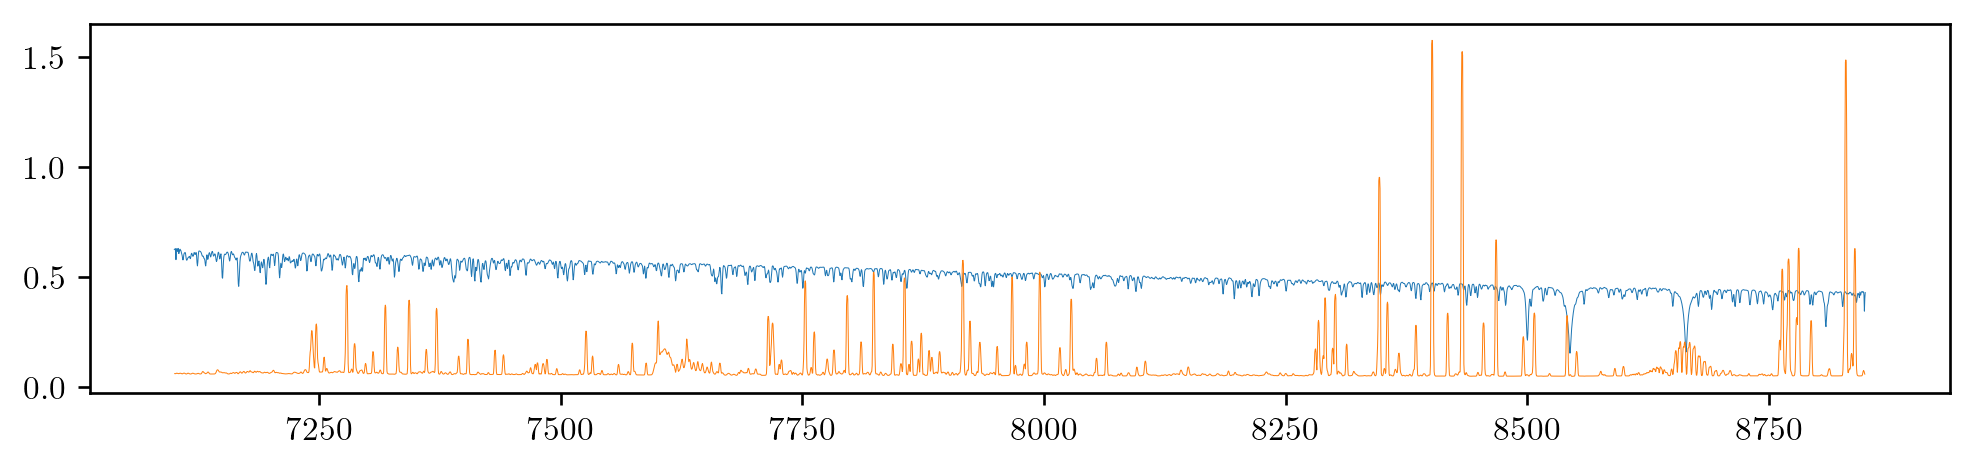

In [7]:
i = 0

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)
ax.plot(wave, flux[i, :], lw=0.3)
ax.plot(wave, flux_err[i, :], lw=0.3)

# Load the training set

In [8]:
with np.load(TRAINING_FILE) as npz:
    training = {k: npz[k].copy() for k in npz.files}

list(training.keys())

['nl',
 'flux',
 'noisy',
 'wave',
 'flux_err',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00']

In [9]:
training['wave'].shape, training['flux'].shape

((4096,), (50000, 4096))

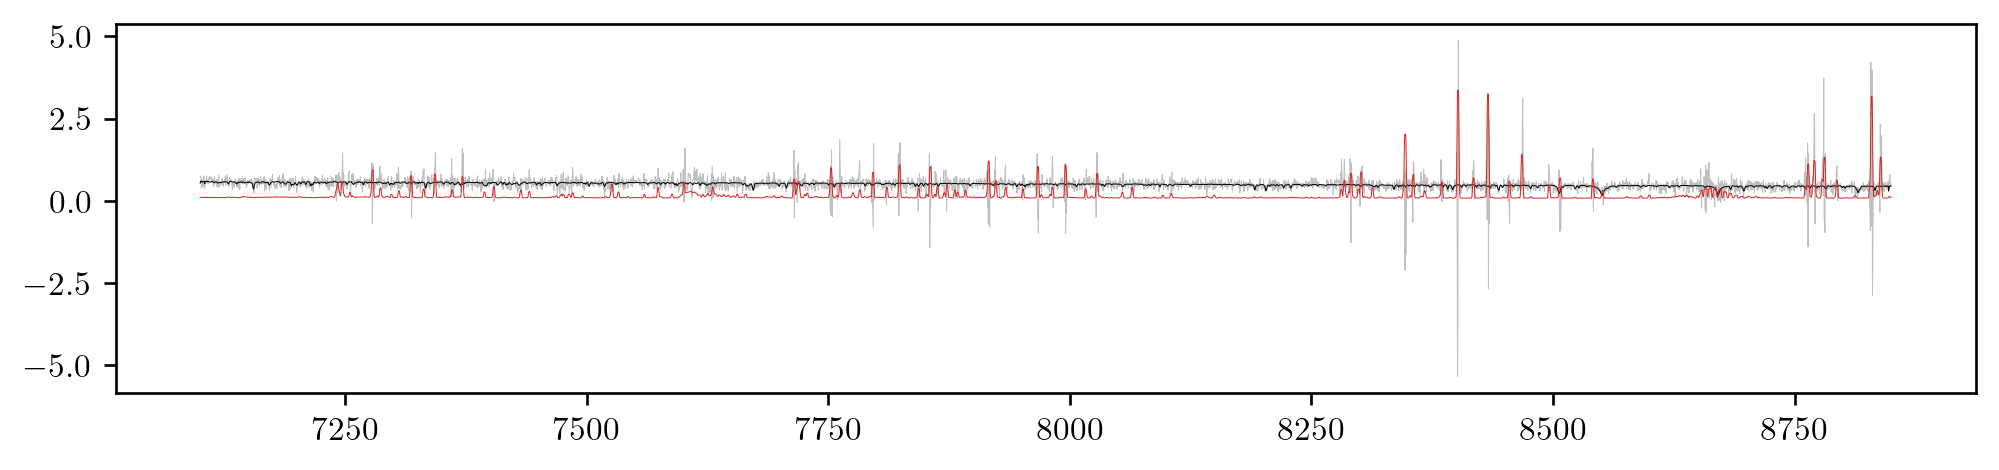

In [10]:
i = 0

w = training['wave']

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f = training['noisy'][i, :]
ax.plot(w, f, lw=0.3, c='gray', alpha=0.5)

f = training['flux'][i, :]
ax.plot(w, f, lw=0.3, c='k')

f = training['flux_err'][i, :]
ax.plot(w, f, lw=0.3, c='tab:red')

# Load the denoised data

In [11]:
wave_mask = np.load(DENOISED_MASK)
wave_mask.shape, wave_mask.sum()

((4096,), 3481)

In [12]:
with np.load(DENOISED_FILE) as npz:
    denoised = {k: npz[k].copy() for k in npz.files}

list(denoised.keys())

['wave',
 'flux',
 'noisy',
 'flux_err',
 'denoised',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00',
 'snr_noisy_db',
 'snr_denoised_db',
 'nl',
 'ckpt',
 'config',
 'mask_path',
 'source_npz']

In [13]:
denoised['wave'].shape, denoised['flux'].shape

((3481,), (50000, 3481))

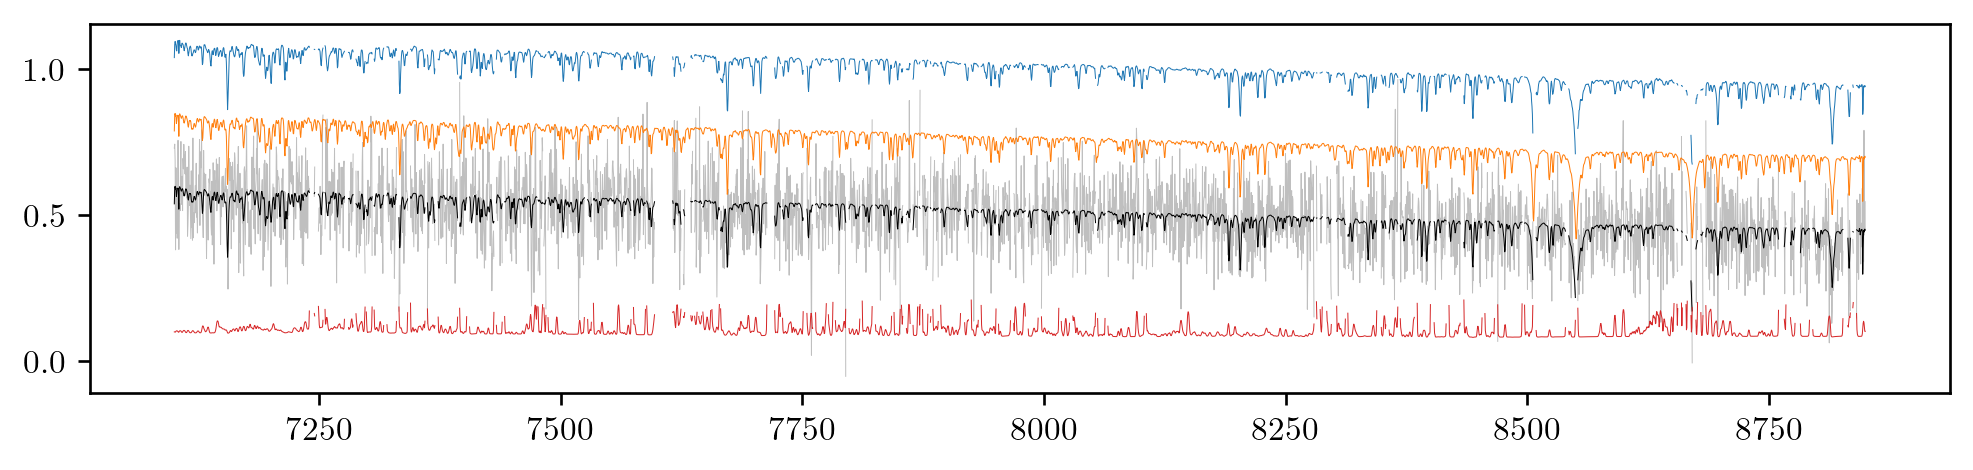

In [14]:
i = 0

w = wave
f = np.full_like(wave, np.nan)

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

f[wave_mask] = denoised['flux'][i, :]
ax.plot(wave, f, lw=0.3, c='k')

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f + 0.5, lw=0.3, c='tab:blue')

f[wave_mask] = denoised['flux_err'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:red')

f = training['flux'][i, :]
ax.plot(wave, f + 0.25, lw=0.3, c='tab:orange')

# Find interesting models

In [15]:
m = (denoised['logg'] > 4.5) & (denoised['teff'] > 5000) & (denoised['mh'] > -0.5) & (np.abs(denoised['rv']) < 20)

np.where(m)

(array([ 2696,  2759,  4141, 11964, 12005, 18568, 19623, 24630, 24811,
        29456, 30036, 33826, 34165, 34582, 39964, 44248, 45721, 47302]),)

# Calculate the equivalent widths

In [16]:
def calculate_continuum(wave, flux, wave_line, wave_c1, wave_c2):
    # flux_c1 = np.median(flux[(wave_c1[0] <= wave) & (wave <= wave_c1[1])])
    # flux_c2 = np.median(flux[(wave_c2[0] <= wave) & (wave <= wave_c2[1])])

    m = np.isfinite(flux)

    mask_line = m & (wave_line[0] <= wave) & (wave <= wave_line[1])
    mask_c1 = m & (wave_c1[0] <= wave) & (wave <= wave_c1[1])
    mask_c2 = m & (wave_c2[0] <= wave) & (wave <= wave_c2[1])
    
    flux_c1 = np.quantile(flux[mask_c1], 0.5)
    flux_c2 = np.quantile(flux[mask_c2], 0.5)

    flux_continuum = flux_c1 + (flux_c2 - flux_c1) * (wave[mask_line] - wave_line[0]) / (wave_line[1] - wave_line[0])

    return wave[mask_line], flux_continuum, flux_c1, flux_c2

def calculate_ew(wave, flux, wave_line, wave_c1, wave_c2):
    # Calculate the equivalent width of a spectral line
    # wave: wavelength array
    # flux: flux array
    # wave_line: central wavelength of the line
    # wave_c1: start wavelength of the continuum region
    # wave_c2: end wavelength of the continuum region

    m = np.isfinite(flux)
    mask_line = m & (wave_line[0] <= wave) & (wave <= wave_line[1])

    _, flux_continuum, flux_c1, flux_c2 = calculate_continuum(wave, flux, wave_line, wave_c1, wave_c2)

    # Line flux is the original flux
    flux_line = flux[mask_line]
    
    # Continuum flux is the straight line connecting the mean flux centers on the c1 and c2 intervals
    
    ew = np.trapz(1 - flux_line / flux_continuum, wave[mask_line])
    
    return ew

In [17]:
def air_to_vac(wave_air):
    wave_vac = specutils.utils.wcs_utils.air_to_vac(wave_air * u.AA)
    return wave_vac.value

In [18]:
air_to_vac(8498.0)

8500.463545815195

In [19]:
# lick = {
#     'TiO_4': [7643.25, 7717.25, 7527.0, 7577.75, 7735.5, 7782.75],
#     # 'NaI_V12': [8180.0, 8200.0, 8164.0, 8173.0, 8233.0, 8244.0],
#     # 'NaI_F13': [8180.0, 8200.0, 8137.0, 8147.0, 8233.0, 8244.0],
#     # 'NaI_LB13': [8180.0, 8200.0, 8143.0, 8153.0, 8233.0, 8244.0],
#     'Ca1_LB13': [8484.0, 8513.0, 8474.0, 8484.0, 8563.0, 8577.0],
#     'Ca2_LB13': [8522.0, 8562.0, 8474.0, 8484.0, 8563.0, 8577.0],
#     'Ca3_LB13': [8642.0, 8682.0, 8619.0, 8642.0, 8700.0, 8725.0]}


EW_DEF = {
    # Manually defined
    # 'CaII8498': {
    #     'latex': R'\mathrm{Ca}\,\textsc{ii}\,8498',
    #     'wave': air_to_vac(8498.0),
    #     'wave_line': air_to_vac([8498.0 - 10, 8498.0 + 10]),
    #     'wave_c1': air_to_vac([8498.0 - 25, 8498.0 - 10]),
    #     'wave_c2': air_to_vac([8498.0 + 10, 8498.0 + 25]),
    # },
    # 'CaII8542': {
    #     'latex': R'\mathrm{Ca}\,\textsc{ii}\,8542',
    #     'wave': air_to_vac(8542.0),
    #     'wave_line': air_to_vac([8542.0 - 20, 8542.0 + 20]),
    #     'wave_c1': air_to_vac([8542.0 - 35, 8542.0 - 20]),
    #     'wave_c2': air_to_vac([8542.0 + 20, 8542.0 + 35]),
    # },
    # 'CaII8662': {
    #     'latex': R'\mathrm{Ca}\,\textsc{ii}\,8662',
    #     'wave': air_to_vac(8662.0),
    #     'wave_line': air_to_vac([8662.0 - 22.5, 8662.0 + 22.5]),
    #     'wave_c1': air_to_vac([8662.0 - 37.5, 8662.0 - 22.5]),
    #     'wave_c2': air_to_vac([8662.0 + 22.5, 8662.0 + 37.5]),
    # },

    # Lick index definition
    'CaII8498': {
        'latex': R'\mathrm{Ca}\,\textsc{ii}\,8498',
        'wave': air_to_vac(8498.0),
        'wave_line': air_to_vac([8484.0, 8513.0]),
        'wave_c1': air_to_vac([8474.0, 8484.0]),
        'wave_c2': air_to_vac([8563.0, 8577.0]),
    },
    'CaII8542': {
        'latex': R'\mathrm{Ca}\,\textsc{ii}\,8542',
        'wave': air_to_vac(8542.0),
        'wave_line': air_to_vac([8522.0, 8562.0]),
        'wave_c1': air_to_vac([8474.0, 8484.0]),
        'wave_c2': air_to_vac([8563.0, 8577.0]),
    },
    'CaII8662': {
        'latex': R'\mathrm{Ca}\,\textsc{ii}\,8662',
        'wave': air_to_vac(8662.0),
        'wave_line': air_to_vac([8642.0, 8682.0]),
        'wave_c1': air_to_vac([8619.0, 8642.0]),
        'wave_c2': air_to_vac([8700.0, 8725.0]),
    },

    'TiO': {
        'latex': R'\mathrm{TiO}',
        'wave_line': air_to_vac([7643.25, 7717.25]),
        'wave_c1': air_to_vac([7527.0, 7577.75]),
        'wave_c2': air_to_vac([7735.5, 7782.75]),
    }
}

EW_DEF

{'CaII8498': {'latex': '\\mathrm{Ca}\\,\\textsc{ii}\\,8498',
  'wave': 8500.463545815195,
  'wave_line': array([8486.45955193, 8515.4678251 ]),
  'wave_c1': array([8476.45669922, 8486.45955193]),
  'wave_c2': array([8565.48209032, 8579.48608482])},
 'CaII8542': {'latex': '\\mathrm{Ca}\\,\\textsc{ii}\\,8542',
  'wave': 8544.47609875715,
  'wave_line': array([8524.47039274, 8564.481805  ]),
  'wave_c1': array([8476.45669922, 8486.45955193]),
  'wave_c2': array([8565.48209032, 8579.48608482])},
 'CaII8662': {'latex': '\\mathrm{Ca}\\,\\textsc{ii}\\,8662',
  'wave': 8664.510339499604,
  'wave_line': array([8644.50463217, 8684.51604705]),
  'wave_c1': array([8621.498069  , 8644.50463217]),
  'wave_c2': array([8702.52118402, 8727.52831899])},
 'TiO': {'latex': '\\mathrm{TiO}',
  'wave_line': array([7645.46993298, 7719.49100349]),
  'wave_c1': array([7529.18684114, 7579.95128633]),
  'wave_c2': array([7737.74620059, 7785.00965726])}}

In [34]:
# i = 42      # Solar metallicity cool dwarf
# i = 133     # G dwarf, solar metallicity
# i = 2696
i = 4141
# i = 336

/tmp/ipykernel_2987540/1630614894.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


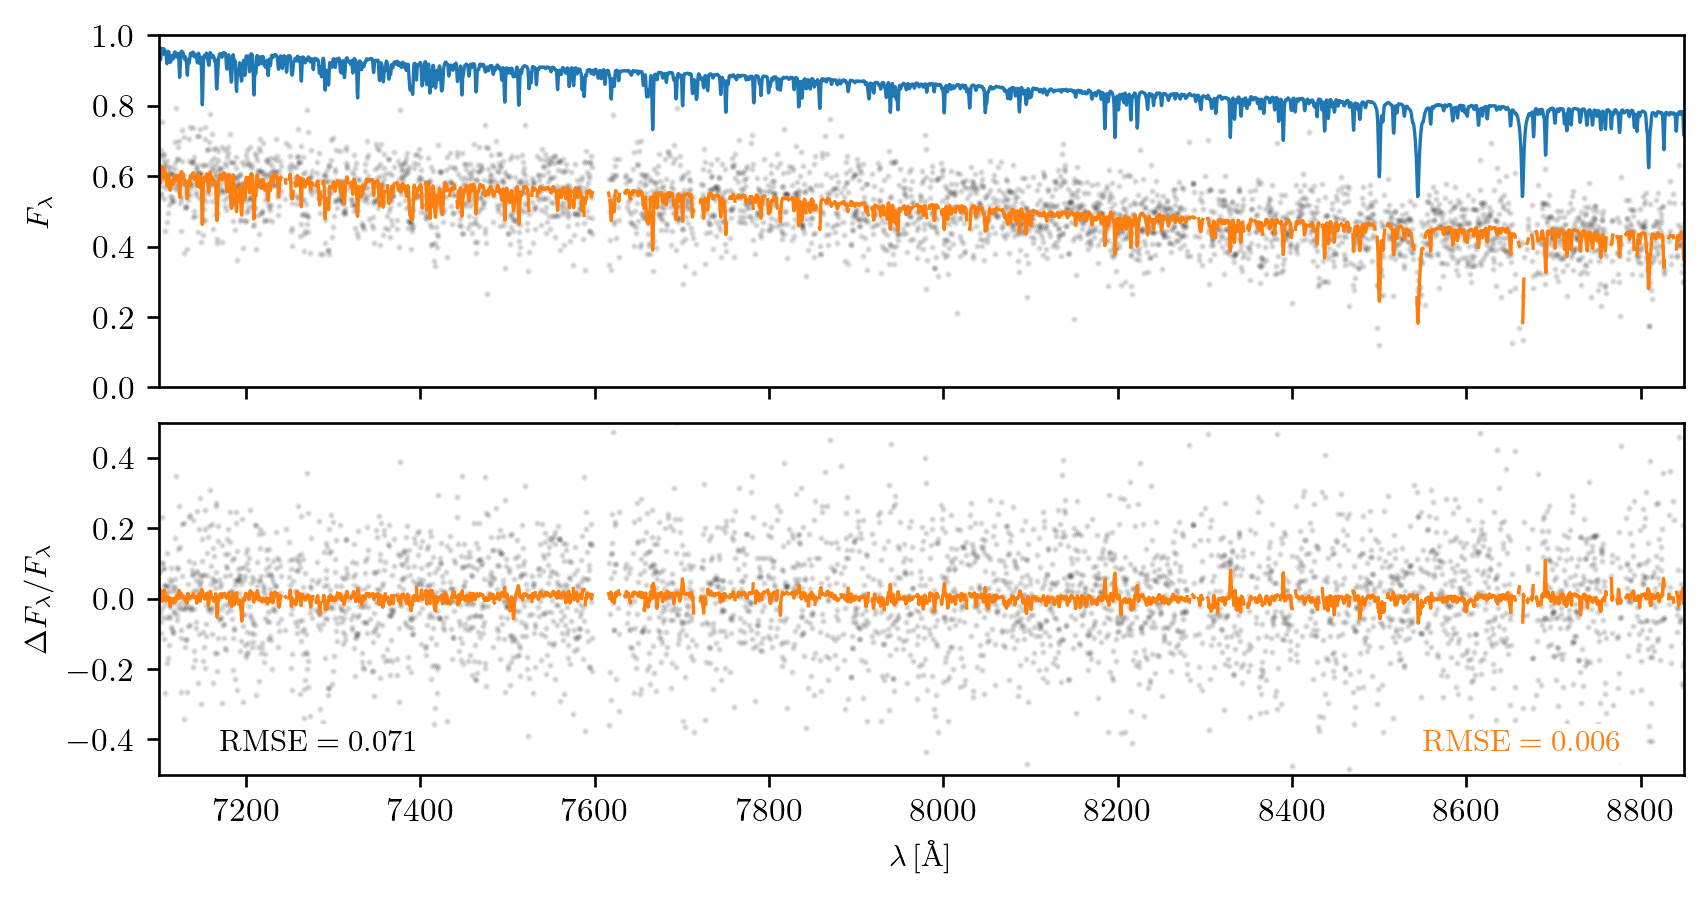

In [61]:
fig, ax = plt.subplots(2, 1, figsize=(8.2, 4), dpi=240, sharex='col', sharey='row',
                         gridspec_kw={'hspace': 0.1, 'wspace': 0.06})

w = wave / (1 + denoised['rv'][i] / 3e5)
f = np.full_like(w, np.nan)
m = np.full_like(w, True, dtype=bool)

### ###

# Noisy

f[wave_mask] = denoised['noisy'][i, :]
ax[0].plot(w[m], f[m], '.', ms=2, color='k', alpha=0.1, rasterized=True)

rmse_noisy = np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2))

# Clean

ax[0].plot(w[m], training['flux'][i, :][m] + 0.35, '-', lw=1.0, color='tab:blue')

# Denoised

f[wave_mask] = denoised['denoised'][i, :]
ax[0].plot(w[m], f[m], '-', lw=1.0, color='tab:orange')

rmse_denoised = np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2))

###

ax[0].set_ylim(0, 1)

ax[0].set_ylabel(R'$F_\lambda$', fontsize=9)

### ###

r = np.full_like(w, np.nan)

r[wave_mask] = (denoised['noisy'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
ax[1].plot(w[m], r[m], '.', ms=2, color='k', alpha=0.1, rasterized=True)

r[wave_mask] = (denoised['denoised'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
ax[1].plot(w[m], r[m], '-', lw=1.0, color='tab:orange')

ax[1].set_xlim(wave[0], wave[-1])
ax[1].set_ylim(-0.5, 0.5)

ax[1].set_xlabel(R'$\lambda\,[\mathrm{\AA}]$', fontsize=9)
ax[1].set_ylabel(R'$\Delta F_\lambda / F_\lambda$', fontsize=9)

ax[1].text(
    0.04, 0.05, fR'$\mathrm{{RMSE}}={rmse_noisy:.3f}$',
    fontsize=9, color='black',
    verticalalignment='bottom', horizontalalignment='left',
    transform=ax[1].transAxes,
    bbox=dict(facecolor='white', edgecolor='none', pad=2)
)

ax[1].text(
    0.96, 0.05, fR'$\mathrm{{RMSE}}={rmse_denoised:.3f}$',
    fontsize=9, color='tab:orange',
    verticalalignment='bottom', horizontalalignment='right',
    transform=ax[1].transAxes,
    bbox=dict(facecolor='white', edgecolor='none', pad=2)
)

fig.tight_layout()
fig.align_ylabels()

fig.savefig(f'../figs/fig_denoised_rel_error.pdf', bbox_inches='tight')

In [58]:
def plot_ew(ew_def, i, ax, buffer=5, cmap=plt.get_cmap('tab10')):
    # Shift spectrum to rest-frame
    w = wave / (1 + denoised['rv'][i] / 3e5)
    f = np.full_like(w, np.nan)
    m = (ew_def['wave_c1'][0] - buffer <= w) & (w <= ew_def['wave_c2'][1] + buffer)

    ### ###

    # Shade the wavelength ranges in the back
    ax[0].axvspan(ew_def['wave_c1'][0], ew_def['wave_c1'][1], lw=0, color='gray', alpha=0.1)
    ax[0].axvspan(ew_def['wave_c2'][0], ew_def['wave_c2'][1], lw=0, color='gray', alpha=0.1)
    ax[0].axvspan(ew_def['wave_line'][0], ew_def['wave_line'][1], lw=0, color='gray', alpha=0.25)

    # Noisy

    f[wave_mask] = denoised['noisy'][i, :]
    ew_noisy = calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    ax[0].plot(w[m], f[m], '.', ms=2, color='k', alpha=0.1, rasterized=True)

    rmse_noisy = np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2))
    
    # wc, fc, fc1, fc2 = calculate_continuum(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    # print(fc, fc1, fc2)
    # ax[0].plot(wc, fc, '--', lw=1.0, color='k')

    # Clean

    ew_clean = calculate_ew(w[m], training['flux'][i, :][m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    ax[0].plot(w[m], training['flux'][i, :][m], '-', lw=1.0, color='tab:blue')

    # wc, fc, fc1, fc2 = calculate_continuum(w[m], training['flux'][i, :][m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    # print(fc, fc1, fc2)
    # ax[0].plot(wc, fc, '--', lw=1.0, color='tab:blue')

    # Denoised

    f[wave_mask] = denoised['denoised'][i, :]
    ew_denoised = calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    ax[0].plot(w[m], f[m], '.', ms=2, color='tab:orange', rasterized=True)

    rmse_denoised = np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2))

    # wc, fc, fc1, fc2 = calculate_continuum(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    # print(fc, fc1, fc2)
    # ax[0].plot(wc, fc, '--', lw=1.0, color='tab:orange')

    ###


    ax[0].set_ylim(0, 0.7)

    ax[0].text(0.04, 0.05, fR'$\mathrm{{EW}}={ew_clean:.2f}$', fontsize=7, color='tab:blue',
               verticalalignment='bottom', horizontalalignment='left', transform=ax[0].transAxes)
    
    ax[0].text(0.5, 0.05, fR'$\mathrm{{EW}}={ew_noisy:.2f}$', fontsize=7, color='black',
               verticalalignment='bottom', horizontalalignment='center', transform=ax[0].transAxes)
    
    ax[0].text(0.96, 0.05, fR'$\mathrm{{EW}}={ew_denoised:.2f}$', fontsize=7, color='tab:orange',
               verticalalignment='bottom', horizontalalignment='right', transform=ax[0].transAxes)

    ### ###

    r = np.full_like(w, np.nan)
    
    r[wave_mask] = (denoised['noisy'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
    ax[1].plot(w[m], r[m], '.', ms=2, color='k', alpha=0.5)

    r[wave_mask] = (denoised['denoised'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
    ax[1].plot(w[m], r[m], '.', ms=2, color='tab:orange', alpha=0.5)

    ax[1].set_ylim(-0.24, 0.24)
   
    ax[1].text(
        0.04, 0.05, fR'$\mathrm{{RMSE}}={rmse_noisy:.3f}$',
        fontsize=7, color='black',
        verticalalignment='bottom', horizontalalignment='left',
        transform=ax[1].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )
    
    ax[1].text(
        0.96, 0.05, fR'$\mathrm{{RMSE}}={rmse_denoised:.3f}$',
        fontsize=7, color='tab:orange',
        verticalalignment='bottom', horizontalalignment='right',
        transform=ax[1].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )

-14.004453591359981


/tmp/ipykernel_2987540/291689278.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


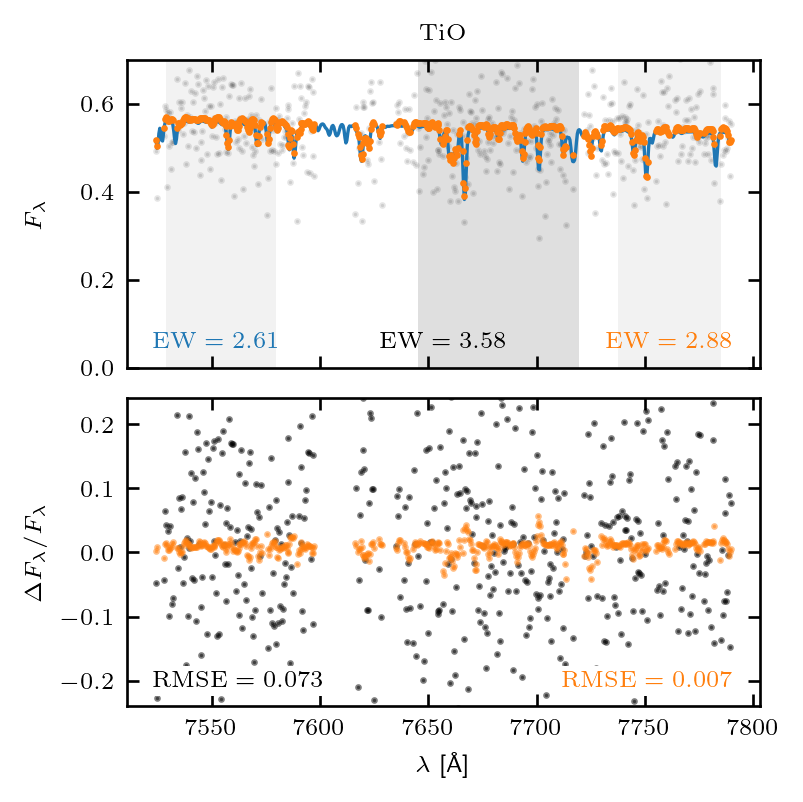

In [59]:
ew_defs = [EW_DEF['TiO']]

print(denoised['rv'][i])

fig, axes = plt.subplots(2, 1, figsize=(3.4, 3.5), dpi=240, sharex='col', sharey='row', squeeze=False,
                         gridspec_kw={'hspace': 0.1, 'wspace': 0.06})

for ax, ew_def in zip(axes.T, ew_defs):

    plot_ew(ew_def, i, ax)
    
for ax, ew_def in zip(axes[0, :], ew_defs):
    ax.set_title(f'${ew_def["latex"]}$', fontsize=7)

for ax in axes[-1, :]:
    ax.set_xlabel(R'$\lambda$ [Å]', fontsize=7)
    
axes[0, 0].set_ylabel(R'$F_\lambda$', fontsize=7)
axes[1, 0].set_ylabel(R'$\Delta F_\lambda / F_\lambda$', fontsize=7)
# axes[1, 0].set_ylabel(R'$(\hat{x} - y) / y$', fontsize=7)

for ax in axes.flatten():
    # All tick inside
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)

# Align the y axis labels
fig.align_ylabels()

fig.tight_layout()

fig.savefig(f'../figs/fig_TiO_{i}.pdf')

-14.004453591359981


/tmp/ipykernel_2987540/1488960943.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


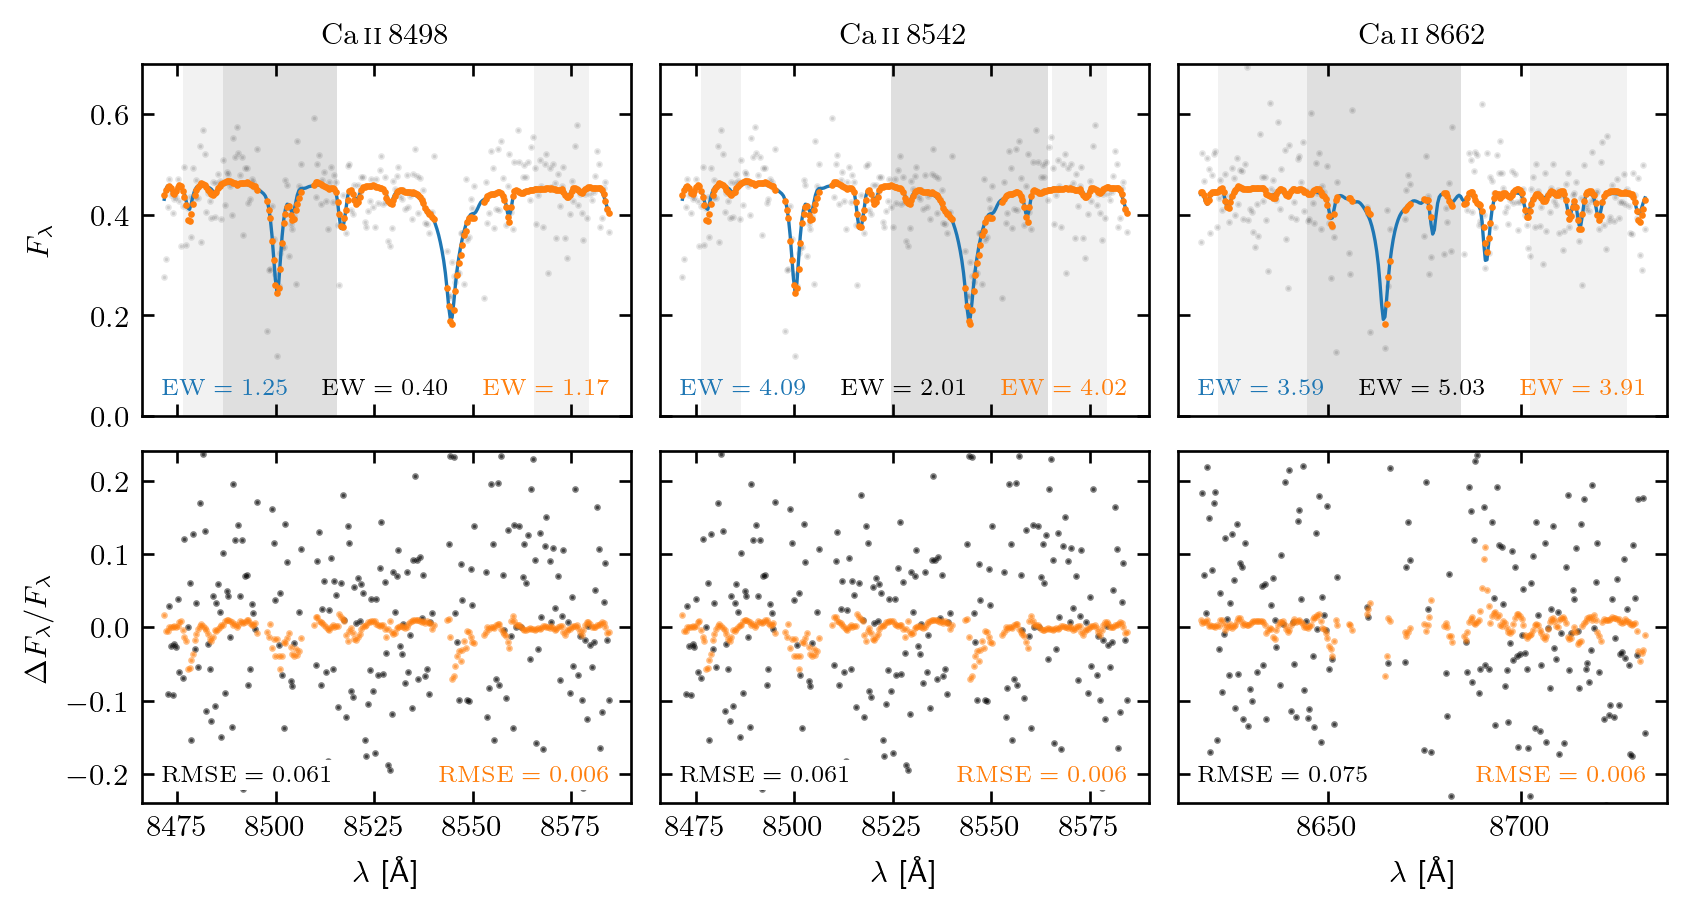

In [60]:
ew_defs = [EW_DEF['CaII8498'], EW_DEF['CaII8542'], EW_DEF['CaII8662']]

print(denoised['rv'][i])

fig, axes = plt.subplots(2, 3, figsize=(8.2, 4), dpi=240, sharex='col', sharey='row',
                         gridspec_kw={'hspace': 0.1, 'wspace': 0.06})

for ax, ew_def in zip(axes.T, ew_defs):

    plot_ew(ew_def, i, ax)
    
for ax, ew_def in zip(axes[0, :], ew_defs):
    ax.set_title(f'${ew_def["latex"]}$', fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel(R'$\lambda$ [Å]', fontsize=9)
    
axes[0, 0].set_ylabel(R'$F_\lambda$', fontsize=9)
axes[1, 0].set_ylabel(R'$\Delta F_\lambda / F_\lambda$', fontsize=9)
# axes[1, 0].set_ylabel(R'$(\hat{x} - y) / y$', fontsize=9)

for ax in axes.flatten():
    # All tick inside
    ax.tick_params(direction='in', top=True, right=True, labelsize=9)

# Align the y axis labels
fig.align_ylabels()

fig.tight_layout()

fig.savefig(f'../figs/fig_CaII_{i}.pdf', bbox_inches='tight')

In [23]:
print('[M/H]', denoised['mh'][i])
print('T_eff', denoised['teff'][i])
print('log g', denoised['logg'][i])
print('snr0', denoised['snr0'][i])
print('snr00', denoised['snr00'][i])

[M/H] 0.25
T_eff 5250.0
log g 5.0
snr0 2.6941905
snr00 8.699171517223803


# Calculate the RMSE for each spectrum

In [63]:
n_items = 10000

rmse_noisy = []
rmse_denoised = []

for i in tqdm(range(n_items)):
    w = wave / (1 + denoised['rv'][i] / 3e5)
    f = np.full_like(w, np.nan)
    m = np.full_like(w, True, dtype=bool)

    f[wave_mask] = denoised['noisy'][i, :]
    rmse_noisy.append(np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2)))

    f[wave_mask] = denoised['denoised'][i, :]
    rmse_denoised.append(np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2)))

  0%|          | 0/10000 [00:00<?, ?it/s]

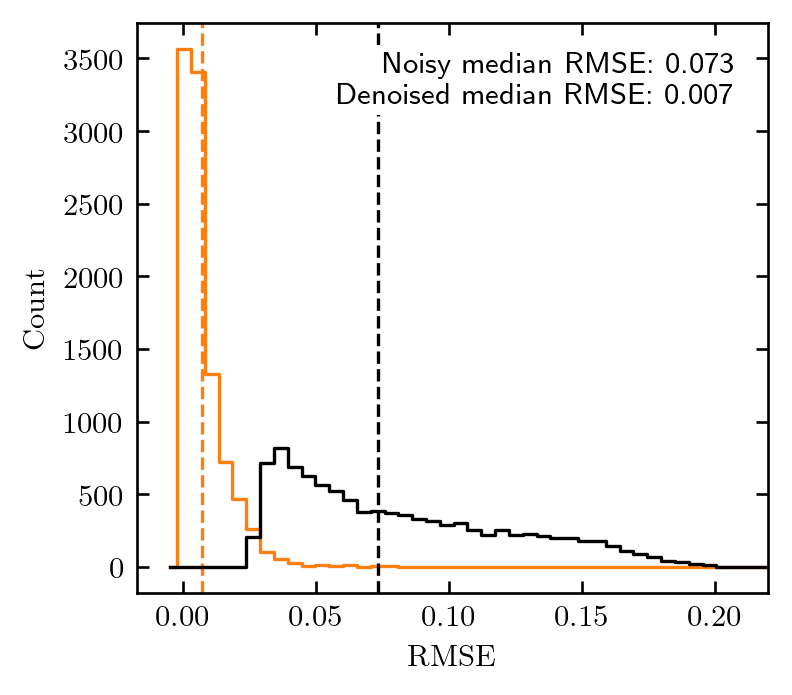

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(3.4, 3), dpi=240)

bins = np.linspace(-0.005, 0.25, 50)

hist, _ = np.histogram(rmse_denoised, bins=bins)
ax.step(bins[:-1], hist, where='mid', label='Denoised', color='tab:orange', lw=1.0)

med_denoised = np.median(rmse_denoised)
ax.axvline(med_denoised, color='tab:orange', lw=1.0, ls='--', label='Denoised median')

hist, _ = np.histogram(rmse_noisy, bins=bins)
ax.step(bins[:-1], hist, where='mid', label='Noisy', color='k', lw=1.0)
med_noisy = np.median(rmse_noisy)
ax.axvline(med_noisy, color='k', lw=1.0, ls='--', label='Noisy median')

ax.text(0.95, 0.95, f'Noisy median RMSE: {med_noisy:.3f}\nDenoised median RMSE: {med_denoised:.3f}',
        fontsize=9, color='k', verticalalignment='top', horizontalalignment='right',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=2)
        )

ax.set_xlim(None, 0.22)

ax.set_xlabel(R'$\mathrm{RMSE}$', fontsize=9)
ax.set_ylabel(R'$\mathrm{Count}$', fontsize=9)

# All tick inside
ax.tick_params(direction='in', top=True, right=True, labelsize=9)

fig.tight_layout()
fig.savefig(f'../figs/fig_rmse_hist.pdf', bbox_inches='tight')

# Calculate the EWs for all stars

In [24]:
buffer = 5
ew_defs = ['CaII8498', 'CaII8542', 'CaII8662', 'TiO']

ew_clean = defaultdict(list)
ew_noisy = defaultdict(list)
ew_denoised = defaultdict(list)

for i in tqdm(range(5)):
    for ewd in ew_defs:
        ew_def = EW_DEF[ewd]

        w = wave / (1 + denoised['rv'][i] / 3e5)
        f = np.full_like(w, np.nan)
        m = (ew_def['wave_c1'][0] - buffer <= w) & (w <= ew_def['wave_c2'][1] + buffer)

        ew_clean[ewd].append(
            calculate_ew(w[m], training['flux'][i, :][m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))

        f[wave_mask] = denoised['noisy'][i, :]
        ew_noisy[ewd].append(
            calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))

        f[wave_mask] = denoised['denoised'][i, :]
        ew_denoised[ewd].append(
            calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))

  0%|          | 0/5 [00:00<?, ?it/s]

In [25]:
from multiprocessing import get_context

buffer = 5
ew_defs = ['CaII8498', 'CaII8542', 'CaII8662', 'TiO']
n_items = 10000  # change to len(denoised['rv']) for all stars


def _compute_ews_for_i(i):
    clean_i = {}
    noisy_i = {}
    denoised_i = {}

    for ewd in ew_defs:
        ew_def = EW_DEF[ewd]

        w = wave / (1 + denoised['rv'][i] / 3e5)
        f = np.full_like(w, np.nan)
        m = (ew_def['wave_c1'][0] - buffer <= w) & (w <= ew_def['wave_c2'][1] + buffer)

        clean_i[ewd] = calculate_ew(
            w[m], training['flux'][i, :][m],
            ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']
        )

        f[wave_mask] = denoised['noisy'][i, :]
        noisy_i[ewd] = calculate_ew(
            w[m], f[m],
            ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']
        )

        f[wave_mask] = denoised['denoised'][i, :]
        denoised_i[ewd] = calculate_ew(
            w[m], f[m],
            ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']
        )

    return i, clean_i, noisy_i, denoised_i


ew_clean = defaultdict(list)
ew_noisy = defaultdict(list)
ew_denoised = defaultdict(list)

ctx = get_context("fork")
with ctx.Pool(processes=12) as pool:
    results = list(tqdm(pool.imap(_compute_ews_for_i, range(n_items)), total=n_items))

for _, clean_i, noisy_i, denoised_i in results:
    for ewd in ew_defs:
        ew_clean[ewd].append(clean_i[ewd])
        ew_noisy[ewd].append(noisy_i[ewd])
        ew_denoised[ewd].append(denoised_i[ewd])

  0%|          | 0/10000 [00:00<?, ?it/s]

In [26]:
df_ew = pd.DataFrame(
    {
        'CaII8498_clean': ew_clean['CaII8498'],
        'CaII8498_noisy': ew_noisy['CaII8498'],
        'CaII8498_denoised': ew_denoised['CaII8498'],

        'CaII8542_clean': ew_clean['CaII8542'],
        'CaII8542_noisy': ew_noisy['CaII8542'],
        'CaII8542_denoised': ew_denoised['CaII8542'],

        'CaII8662_clean': ew_clean['CaII8662'],
        'CaII8662_noisy': ew_noisy['CaII8662'],
        'CaII8662_denoised': ew_denoised['CaII8662'],

        'TiO_clean': ew_clean['TiO'],
        'TiO_noisy': ew_noisy['TiO'],
        'TiO_denoised': ew_denoised['TiO']
    }
)

df_ew

,CaII8498_clean,CaII8498_noisy,CaII8498_denoised,CaII8542_clean,CaII8542_noisy,CaII8542_denoised,CaII8662_clean,CaII8662_noisy,CaII8662_denoised,TiO_clean,TiO_noisy,TiO_denoised
0,1.474055,2.015984,1.114682,4.931350,6.754146,4.321844,4.476182,0.027027,4.404956,3.620907,4.176215,3.484571
1,1.510422,0.919380,1.525155,4.358119,5.540990,4.567743,4.316390,4.952357,4.415584,5.771866,6.209643,5.661765
2,1.483499,1.292661,1.406538,2.247897,2.181742,2.445277,2.653873,2.019430,2.768437,11.620228,11.001266,11.837675
3,0.479006,0.956921,0.649155,1.616285,1.673868,1.405557,1.237270,0.951536,0.710552,0.463620,-0.267871,0.470772
4,0.516102,0.218990,0.654387,1.211617,-0.793695,0.337138,1.226711,1.282283,0.339747,0.512868,1.892840,0.490353
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.706274,1.131102,0.508349,2.184011,3.411377,2.122546,1.724441,0.928088,1.038150,0.772513,1.945443,0.773648
9996,0.489723,-0.939131,0.138959,1.468431,0.523804,1.822730,1.308805,0.143008,1.194328,0.548400,0.835394,0.573939
9997,1.504920,2.579689,1.372083,3.911307,4.832718,3.417179,2.970033,1.848954,3.046056,2.849894,2.976849,2.890509
9998,1.135088,0.186835,1.247997,3.226339,1.478676,3.191900,2.807278,-2.210705,2.304580,1.821838,1.287082,2.046270


In [27]:
EW_DEF[ewd]["latex"]

'\\mathrm{TiO}'

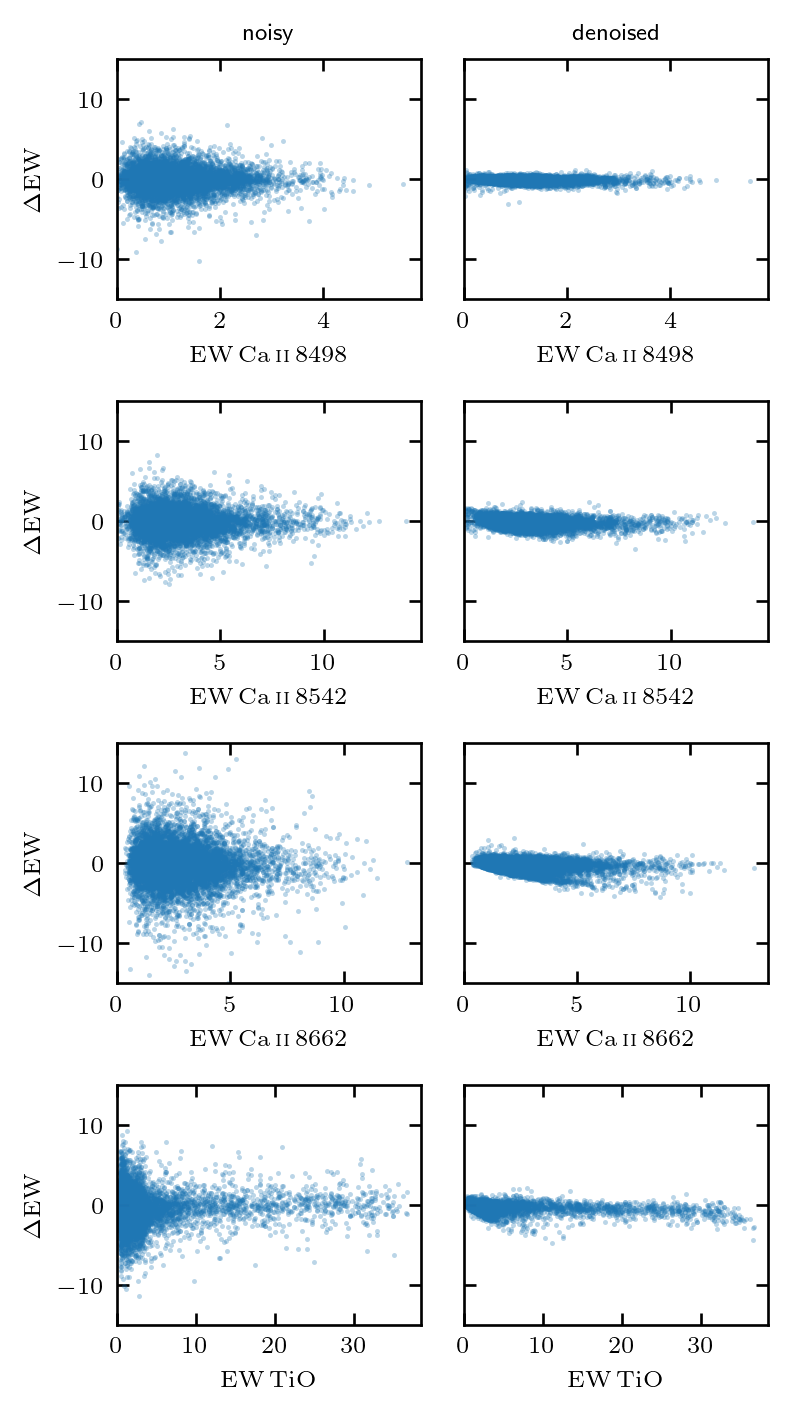

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(3.4, 6), sharey='row', dpi=240)

for ewd, ax in zip(
    ['CaII8498', 'CaII8542', 'CaII8662', 'TiO'],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].plot(df_ew[f'{ewd}_clean'], df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].set_xlim(0, None)
    ax[0].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)
    ax[0].set_ylabel('$\Delta \mathrm{EW}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(df_ew[f'{ewd}_clean'], df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[1].plot([-2, 5], [-2, 5], 'k--')

    ax[1].set_xlim(0, None)
    ax[1].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-15, 15)
    
axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('denoised', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_error.pdf')

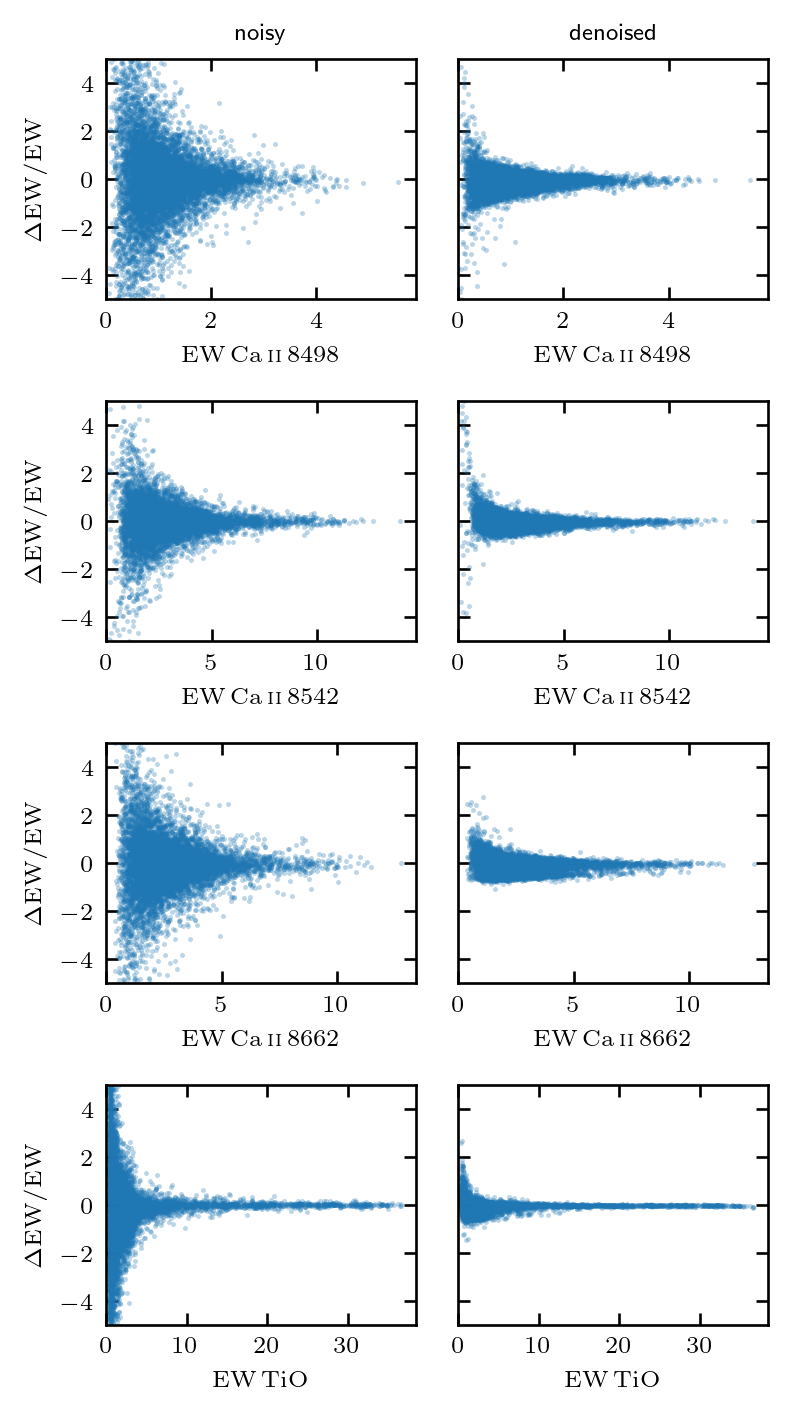

In [29]:
fig, axes = plt.subplots(4, 2, figsize=(3.4, 6), sharey='row', dpi=240)

for ewd, ax in zip(
    ['CaII8498', 'CaII8542', 'CaII8662', 'TiO'],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].plot(df_ew[f'{ewd}_clean'], (df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].set_xlim(0, None)
    ax[0].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)
    ax[0].set_ylabel('$\Delta \mathrm{EW} / \mathrm{EW}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(df_ew[f'{ewd}_clean'], (df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[1].plot([-2, 5], [-2, 5], 'k--')

    ax[1].set_xlim(0, None)
    ax[1].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-5, 5)

axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('denoised', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_rel_error.pdf')

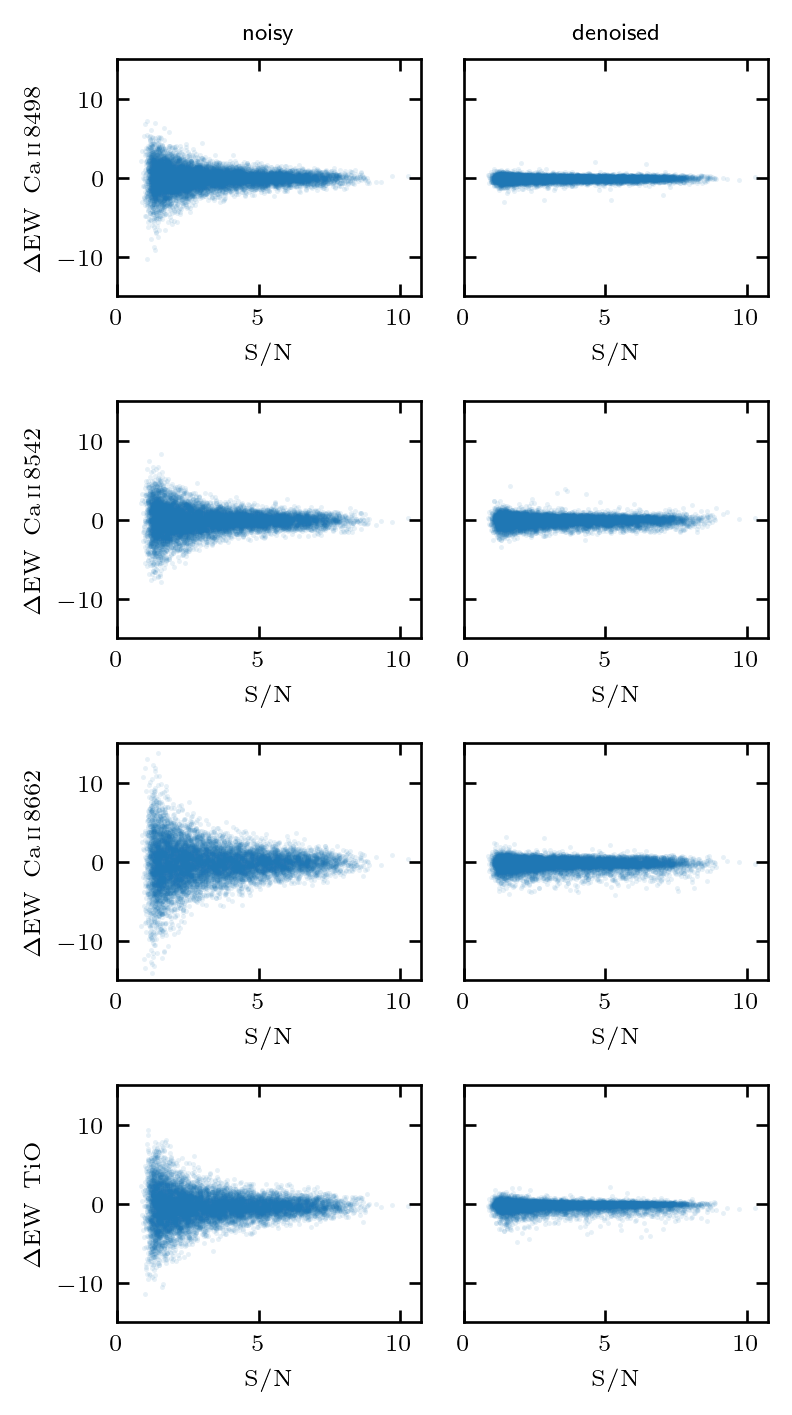

In [30]:
fig, axes = plt.subplots(4, 2, figsize=(3.4, 6), sharey='row', dpi=240)

for ewd, ax in zip(
    ['CaII8498', 'CaII8542', 'CaII8662', 'TiO'],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].plot(denoised['snr0'][:n_items], df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].set_xlim(0, None)
    ax[0].set_xlabel(f'$\\mathrm{{S}}/\\mathrm{{N}}$', fontsize=7)
    ax[0].set_ylabel(f'$\Delta \mathrm{{EW}}\\,\\,\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(denoised['snr0'][:n_items], df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    # ax[1].plot([-2, 5], [-2, 5], 'k--')

    ax[1].set_xlim(0, None)
    ax[1].set_xlabel(f'$\\mathrm{{S}}/\\mathrm{{N}}$', fontsize=7)

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-15, 15)
    
axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('denoised', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_error_snr.pdf')

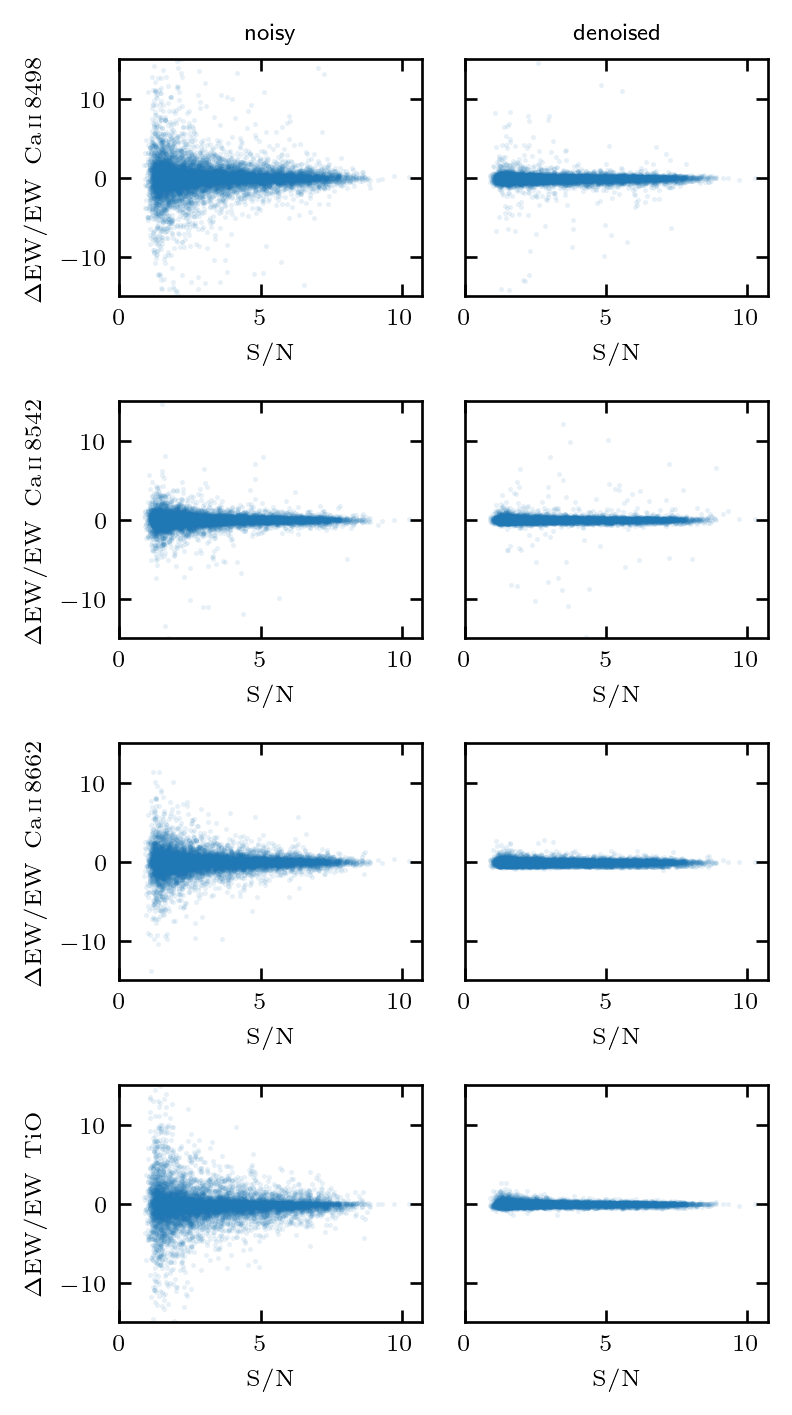

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(3.4, 6), sharey='row', dpi=240)

for ewd, ax in zip(
    ['CaII8498', 'CaII8542', 'CaII8662', 'TiO'],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].plot(denoised['snr0'][:n_items], (df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].set_xlim(0, None)
    ax[0].set_xlabel(f'$\\mathrm{{S}}/\\mathrm{{N}}$', fontsize=7)
    ax[0].set_ylabel(f'$\Delta \mathrm{{EW}} / \mathrm{{EW}}\\,\\,\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(denoised['snr0'][:n_items], (df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    # ax[1].plot([-2, 5], [-2, 5], 'k--')

    ax[1].set_xlim(0, None)
    ax[1].set_xlabel(f'$\\mathrm{{S}}/\\mathrm{{N}}$', fontsize=7)

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-15, 15)
    
axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('denoised', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_rel_error_snr.pdf')

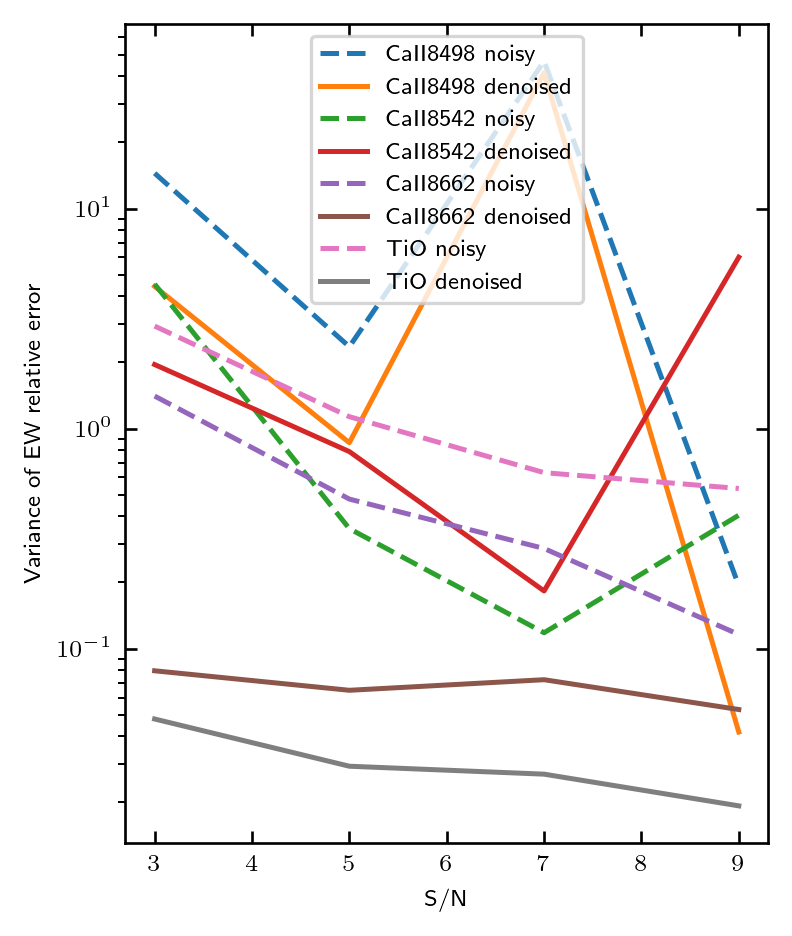

In [32]:
# Calculate the variance of the relative error in S/N bins for
# the noisy and the denoised spectra for each line EW

snr_bins = [[2, 4], [4, 6], [6, 8], [8, 10]]
snr = np.array([snr_min + (snr_max - snr_min) / 2 for snr_min, snr_max in snr_bins])

fig, ax = plt.subplots(1, 1, figsize=(3.4, 4), dpi=240)

for ewd in ['CaII8498', 'CaII8542', 'CaII8662', 'TiO']:
    rel_err_noisy_all = []
    rel_err_denoised_all = []
    for snr_min, snr_max in snr_bins:
        mask = (denoised['snr0'][:n_items] >= snr_min) & (denoised['snr0'][:n_items] < snr_max)
        mask[(df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean']) > 10] = False
        rel_err_noisy = (df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean'])[mask] / df_ew[f'{ewd}_clean'][mask]
        rel_err_denoised = (df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean'])[mask] / df_ew[f'{ewd}_clean'][mask]
        var_noisy = np.var(rel_err_noisy)
        var_denoised = np.var(rel_err_denoised)
        rel_err_noisy_all.append(var_noisy)
        rel_err_denoised_all.append(var_denoised)

    ax.plot(snr, rel_err_noisy_all, '--', label=f'{ewd} noisy', ms=4)
    ax.plot(snr, rel_err_denoised_all, '-', label=f'{ewd} denoised', ms=4)

ax.set_xlabel('S/N', fontsize=7)
ax.set_ylabel('Variance of EW relative error', fontsize=7)
ax.tick_params(direction='in', top=True, right=True, labelsize=7)
ax.legend(fontsize=7)
ax.set_yscale('log')
fig.tight_layout()